# Analyse de la Complexité Théorique du Problème

## Rappel des différents problèmes :

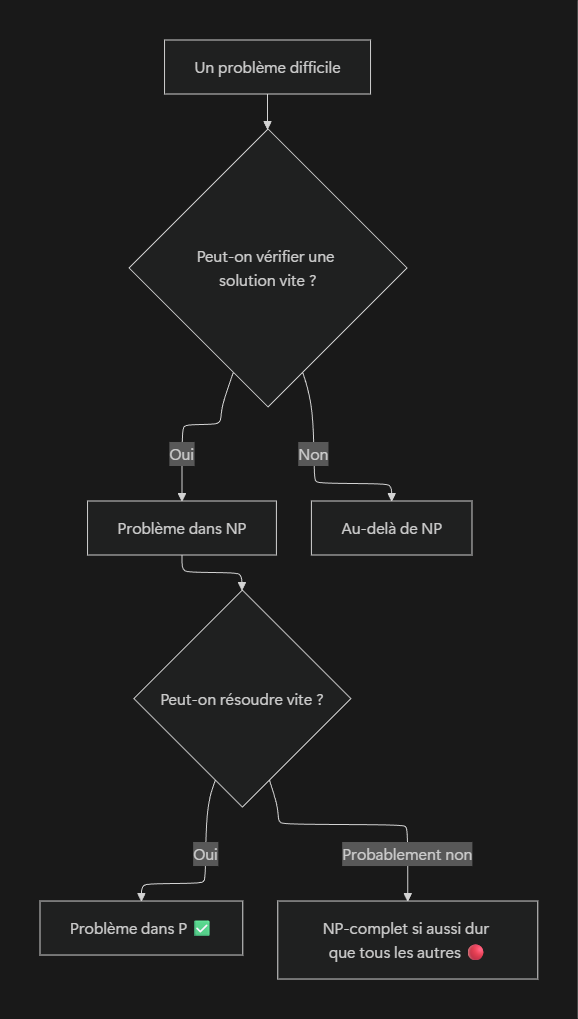

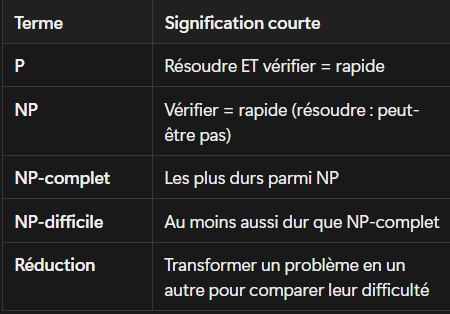

# 1. Pourquoi évaluer la difficulté de notre problème ?

Avant de développer des algorithmes pour optimiser les tournées de nos véhicules, il est essentiel de comprendre la nature mathématique du problème auquel nous sommes confrontés. En informatique théorique, tous les problèmes ne se valent pas, certains peuvent être résolus rapidement, quelle que soit leur taille, tandis que d'autres voient leur temps de résolution exploser dès que l'on ajoute quelques variables.

Dans le cadre de cet appel à projets de l'ADEME, nous devons traiter des réseaux de transport à l'échelle de territoires entiers. Notre modèle doit gérer plusieurs véhicules, respecter des capacités maximales et garantir un équilibrage de la charge de travail entre les chauffeurs. L'objectif de cette section est de démontrer formellement la complexité de ces problèmes.

## 2. Énoncé du Théorème

### A. Le Problème de Décision

Le problème d'optimisation des tournées de véhicules avec capacités et équilibrage de charge (que nous nommerons CVRP-Équilibré) est un problème NP-difficile.

En termes simples, qualifier un problème de "NP-difficile" signifie qu'il n'existe à ce jour aucun algorithme connu capable de trouver la solution absolument parfaite en un temps d'exécution raisonnable (polynomial) pour toutes les instances du problème.

Transformons notre problème d'optimisation (trouver le trajet le plus court) en un problème de décision.

La question que l'on pose à l'algorithme devient :
"Étant donné notre réseau de villes, nos véhicules, nos contraintes de capacité et d'équilibrage, existe-t-il un ensemble de tournées dont le coût total est inférieur ou égal à une valeur cible $C$ ?"

### B. L'Algorithme de Vérification

```
Fonction VerifierSolution(Routes, Demandes, MatriceCouts, CapaciteMax, L_min, L_max, Cible_C):
    CoutTotal = 0
    VillesLivrees = Liste vide

    // On analyse la tournée de chaque véhicule
    Pour chaque route_vehicule k dans Routes:
        ChargeVehicule = 0
        NbVillesVisitees = longueur(Routes[k]) - 2  // On exclut le dépôt de départ et d'arrivée

        // Vérification 1 : Équilibrage de la charge
        Si NbVillesVisitees < L_min ou NbVillesVisitees > L_max:
            Retourner FAUX (Le chauffeur est sous-exploité ou sur-exploité)

        // Parcours de la route étape par étape
        Pour chaque etape i de 0 à longueur(Routes[k]) - 2:
            VilleActuelle = Routes[k][i]
            VilleSuivante = Routes[k][i+1]

            // On cumule la distance du trajet
            CoutTotal = CoutTotal + MatriceCouts[VilleActuelle][VilleSuivante]

            // On livre la ville suivante
            ChargeVehicule = ChargeVehicule + Demandes[VilleSuivante]
            Ajouter VilleSuivante à VillesLivrees

        // Vérification 2 : Capacité du véhicule
        Si ChargeVehicule > CapaciteMax:
            Retourner FAUX (Le véhicule est en surcharge)

    // Vérification 3 : Toutes les villes ont-elles été livrées exactement une fois ?
    Si VillesLivrees contient des doublons ou s'il manque des villes:
        Retourner FAUX (Erreur de livraison)

    // Vérification 4 : Le coût total respecte-t-il l'objectif cible ?
    Si CoutTotal > Cible_C:
        Retourner FAUX (L'objectif de rentabilité n'est pas atteint)

    Retourner VRAI (La solution est valide et respecte toutes les règles)
```

À la lecture du pseudo-code de vérification, on observe une structure de deux boucles imbriquées (une boucle parcourant les véhicules, contenant une boucle parcourant les étapes de la route). En algorithmique classique, des boucles imbriquées suggèrent souvent une complexité quadratique de l'ordre de $O(n^2)$. Cependant, une analyse de notre structure de données démontre que notre algorithme s'exécute en réalité en un temps linéaire, soit $O(n)$, où $n$ est le nombre total de villes à livrer.

Imaginons concrètement que nous avons $n = 100$ clients à livrer, et que notre solution utilise $k = 4$ camions. La première ligne de notre algorithme nous dit : Pour chaque vehicule k dans Routes. Le rôle de cette première boucle est purement organisationnel. Elle va s'exécuter exactement 4 fois. À chaque passage, elle prend un nouveau camion, regarde son carnet de route, et remet les compteurs à zéro (la charge du véhicule redevient 0).

### Par exemple :

On pourrait se dire que nous sommes dans une boucle à l'intérieur d'une autre boucle, donc on multiplie tout. $4 \text{ camions} \times 100 \text{ villes} = 400 \text{ opérations}$.

MAIS

Ce n'est pas ce que nous faisons. En effet, la boucle interne ne parcourt pas les 100 villes à chaque fois. Elle parcourt uniquement la part de travail du camion actuel.

Au tour 1, le camion 1 a 25 livraisons à faire. La boucle interne tourne 25 fois.

Au tour 2, le camion 2 a 25 livraisons à faire. La boucle interne tourne 25 fois.

Au tour 3, le camion 3 a 25 livraisons à faire. La boucle interne tourne 25 fois.

Au tour 4, le camion 4 a 25 livraisons à faire. La boucle interne tourne 25 fois.

### _____________________________________________________________________________________

Au total, l'ordinateur n'a fait que $25 + 25 + 25 + 25 = 100$ opérations

Nous avons un autre problème.
Nous devons vérifier à chaque fois qu'on ne livre pas une deuxième fois une ville.
On ajoute donc chaque client livré dans une table de hachage appelée VillesLivrees. À chaque nouvelle livraison, on vérifie si le client n'est pas déjà dans la boîte

En Python, si on utilise un set (un ensemble), l'ordinateur utilise une formule mathématique appelée "hachage". Quand on demande "Le client 99 est-il là ?", la formule calcule instantanément l'adresse mémoire exacte où le client 99 est censé être rangé. L'ordinateur regarde directement cette case, sans lire les autres. Cette vérification est immédiate et prend toujours le même temps, que l'on ait 10 ou 10 000 clients. En algorithmique, on appelle cela un temps constant, noté $O(1)$.

_

Par conséquent, puisque notre programme effectue un nombre limité d'opérations instantanées exactement $n$ fois, le temps de réponse total de notre algorithme de vérification grandira de manière purement proportionnelle au nombre de clients. C'est la définition même d'une complexité linéaire en $O(n)$.

## Synthèse Théorique

D'une part, grâce à notre algorithme de vérification, nous avons prouvé qu'il est possible de vérifier la validité d'une solution en temps linéaire. Cette rapidité de vérification est la condition stricte pour qu'un problème décisionnel appartienne à la classe NP.

D'autre part, notre problème est intrinsèquement NP-Difficile, et ce pour deux raisons majeures qui se superposent. La première, comme nous l'avons démontré par restriction, est que la recherche d'itinéraire englobe le Problème du Voyageur de Commerce. Mais la seconde raison, concerne la contrainte de capacité. En effet, même si l'on ignorait totalement les distances géographiques et que l'on cherchait uniquement à répartir les demandes des clients dans nos camions sans dépasser leur limite de charge, nous retomberions sur le problème de Bin Packing. Ce problème de remplissage, est lui-même mondialement reconnu comme étant NP-Difficile.

Pour résumer, notre problème combine deux défis majeurs en algorithmique : trouver le chemin le plus court (le Problème du Voyageur de Commerce) et optimiser le chargement des véhicules (le Problème de Bin Packing). Ces deux problèmes étant mathématiquement classés comme NP-Difficiles, leur combinaison rend logiquement notre modèle de transport tout aussi complexe à résoudre.

En pratique, cette complexité se traduit par ce qu'on appelle une "explosion combinatoire". Le nombre de tournées possibles se multiplie de façon vertigineuse à chaque fois que l'on ajoute un client. Si un ordinateur peut facilement tester toutes les options pour 10 villes, la tâche devient impossible pour une échelle territoriale réaliste de 50 points de livraison. Il y a un tel nombre de combinaisons que même les machines les plus puissantes mettraient des années à toutes les évaluer pour garantir un trajet absolument parfait.

Puisqu'une méthode de calcul exacte prendrait beaucoup trop de temps, nous allons utiliser des algorithmes d'optimisation approchée (les heuristiques et métaheuristiques). L'objectif n'est plus de chercher la perfection absolue, mais d'explorer les possibilités pour fournir une solution très performante. Cela nous permettra d'optimiser les tournées, de réduire l'impact carbone et de respecter des temps de calcul de quelques secondes, comme l'exige la réalité du terrain.